# Project: Insurance Cost Prediction

**Overview:** Predict medical charges (regression) and smoker status (classification) using gradient descent and scikit-learn baselines.

**Task:** Regression + binary classification
**Dataset:** Insurance dataset (loaded via URL in the notebook).


## Problem Understanding and Dataset Description
1. Understanding the Problem

In this challenge, I will apply machine learning to a health insurance dataset to predict healthcare related outcomes. In the first task, I will work on a regression problem and predict individual medical charges based on features such as age, BMI, smoking status and region. In the second task, I will work on a binary classification problem that involves predicting whether an individual is a smoker. In both tasks I will implement gradient descent from scratch and compare the results with scikit-learn models.

2. Dataset Description

The dataset variables include:

*   age: Age of the beneficiary
*   sex: Gender (female/male)
*   bmi: Body Mass Index
*   children: Number of dependents
*   smoker: Whether the individual smokes
*   region: Residential region
*   charges: Medical cost (Target variable)

The dataset contains a mixture of categorical features (i.e. sex, smoker, region) and numerical features (i.e. age, bmi, children, charges). Handling mixed data types requires appropriate preproccessing such as encoding for categorical fields and scaling for numeric features.

3. Insights and Assumptions

*   Assumption 1: Older people will have higher medical charges
*   Assumption 2: Health related features such as bmi and smoker status will be a strong predictor of medical cost .
*   Assumption 3: Other features such as sex, number of children and region could have lesser influence on the outcomes.


## Imports and Setup

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

In [4]:
dataset_url = "https://raw.githubusercontent.com/zaka-ai/medical-cost-prediction/refs/heads/master/data/insurance.csv"
df = pd.read_csv(dataset_url)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Data Exploration (EDA)

### Lets begin with looking at the shape of dataset and checking for missing values

In [5]:
df_shape = df.shape
print(df.describe())
# df.info()
print(df.isnull().sum())
print(f"The dataset contains {df_shape[0]} examples and {df_shape[1]} features")

               age          bmi     children       charges
count  1338.000000  1335.000000  1338.000000   1338.000000
mean     39.207025    30.661423     1.094918  13270.422265
std      14.049960     6.101038     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.302500     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.687500     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010
age         0
sex         0
bmi         3
children    0
smoker      0
region      0
charges     0
dtype: int64
The dataset contains 1338 examples and 7 features


That's great! We don't have missing data for all columns except (BMI) in which 3 values are missing.

### Visualizations (EDA)

Let's check how output values (medical charges) are distributed using a histogram

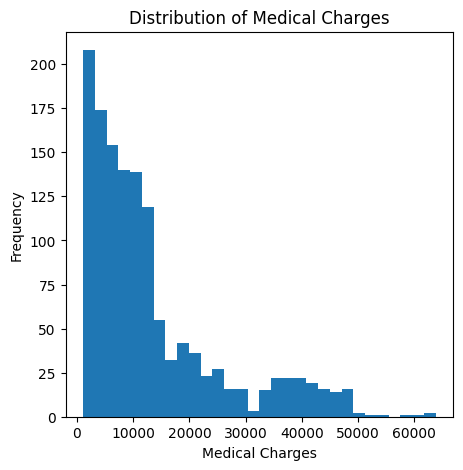

In [6]:
plt.figure(figsize=(5,5))
plt.hist(df["charges"], bins=30)
plt.xlabel("Medical Charges")
plt.ylabel("Frequency")
plt.title("Distribution of Medical Charges")
plt.show()

The distribution is right-skewed showing that most cases have relatively low to moderate medical costs, while a smaller number of cases have very high charges. This suggests the presence of outliers.

My first assumption is that medical costs increase with age, lets check if true.

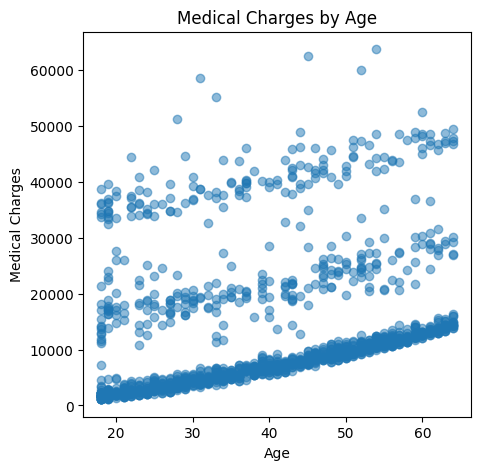

In [7]:
plt.figure(figsize=(5,5))
plt.scatter(df["age"], df["charges"], alpha=0.5)
plt.xlabel("Age")
plt.ylabel("Medical Charges")
plt.title("Medical Charges by Age")
plt.show()

The scatter plot shows that costs increase gradually with age. However, for the same age groups, 3 clusters are clearly visible in the plot. This tells us that some other factors increase the costs significantly.

My second assumption is that smoking and bmi will increase costs. Lets check the effect of these features.

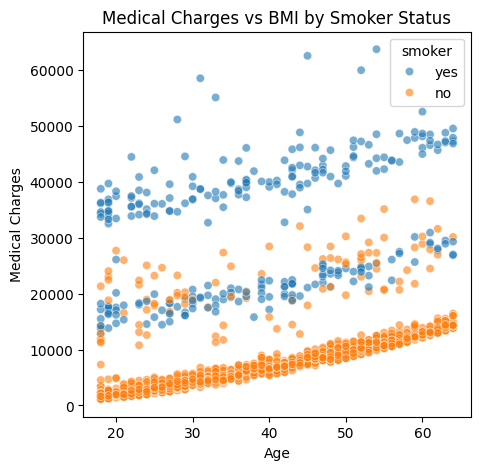

In [8]:
plt.figure(figsize=(5,5))
sns.scatterplot(
    data=df,
    x="age",
    y="charges",
    hue="smoker",
    alpha=0.6
)
plt.xlabel("Age")
plt.ylabel("Medical Charges")
plt.title("Medical Charges vs BMI by Smoker Status")
plt.show()

The scatter plot shows clearly that smokers tend to have higher medical charges. Upper clusters are mostly smokers. The middle cluster shows a mix between smokers and non-smokers. Other factor is influencing the cost but not as much as smoking. Most likely BMI (health factor).

Lets check the effect of BMI

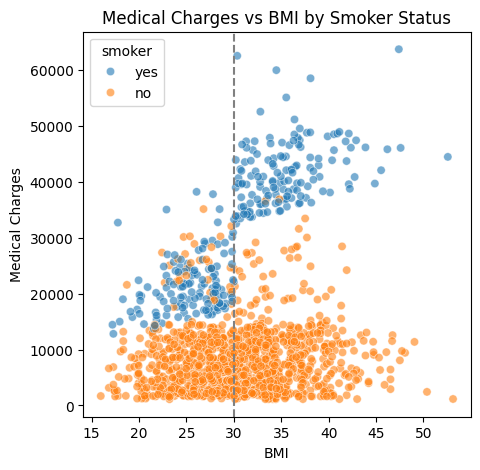

In [9]:
plt.figure(figsize=(5,5))
sns.scatterplot(data=df, x="bmi", y="charges", hue ="smoker", alpha=0.6)
plt.axvline(x=30, color='gray', linestyle='--') # sudden increase when BMI >= 30
plt.xlabel("BMI")
plt.ylabel("Medical Charges")
plt.title("Medical Charges vs BMI by Smoker Status")
plt.show()

For non-smokers, charges increase with BMI but mostly stay below 30,000. Smokers charges are much higher, especially when BMI is more than 30 (as shown by the dotted line).

Low charges: non-smokers with BMI < 30

Medium charges: non-smokers with BMI > 30 or smokers with BMI < 30

High charges: smokers with BMI > 30

## Data Preprocessing and Feature Engineering

First we will fill missing values in BMI column with the median

In [10]:
df['bmi'].fillna(df['bmi'].median(), inplace=True)

/tmp/ipython-input-1439978410.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].median(), inplace=True)


Next, we will do label encoding for binary categorical features

In [11]:
df["smoker"] = df["smoker"].map({"yes": 1, "no": 0})
df["sex"] = df["sex"].map({"male": 1, "female": 0})

For region column, we will do one-hot encoding as it has more than 2 categories

In [12]:
df = pd.get_dummies(df, columns=["region"], drop_first=True, dtype=int)

Next, we will do standarization, as it is necessary for gradient descent to ensure that all features will contribute evenly to the model

In [13]:
scaler = StandardScaler()
numeric_features = ["age", "bmi", "children"]
df[numeric_features] = scaler.fit_transform(df[numeric_features])

## Part 1: Medical Cost Prediction

Next step is to build our models. I will start with gradient descent from scratch using loops.

###Using Loops

In [14]:
# We need to Log transform the target to fix the distribution
y = np.log(df["charges"].values)

# remove the y values
X = df.drop(columns=["charges"]).values

# Add bias column (w0)
X = np.c_[np.ones(X.shape[0]), X]

# split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Define the loss function (we will use Mean Squared Error)
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# Define Gradient Descent function
def gradient_descent_loop (X, y, learning_rate = 0.01, n_iterations = 5000):
  n_examples = X.shape[0] #number of examples
  n_features = X.shape[1] #number of features

  #initialize the weights vector
  weights = np.zeros(n_features)

  for n in range(n_iterations):

    #Set the predicted values to 0 with each iteration
    y_pred = np.zeros(n_examples)

    #calculate the predicted values
    for i in range(n_examples):
      for j in range(n_features):
        y_pred[i] = y_pred[i] + (weights[j] * X[i, j])  #sum over all the features

    #calculate the gradients
    gradients = np.zeros(n_features)
    for j in range(n_features):
      gradients_sum = 0
      for i in range(n_examples):
        gradients_sum += -2 * X[i, j] * (y[i] - y_pred[i]) #gradient of mse
      gradients[j] = gradients_sum / n_examples

    #update the weights
    for j in range(n_features):
      weights[j] = weights[j] - gradients[j] * learning_rate

  return weights


Train the Model


In [15]:
weights_loop = gradient_descent_loop(X_train, y_train)

y_pred_loop = np.zeros(X_test.shape[0])

#Calculate predicted values using the weights from training
for i in range(X_test.shape[0]):
    for j in range(X_test.shape[1]):
        y_pred_loop[i] += weights_loop[j] * X_test[i, j]

loop_mse = mse(y_test, y_pred_loop)

Lets check the Error

In [16]:
print(loop_mse)

0.1758554518831256


### Using Scikit-Learn

In [17]:
lr = LinearRegression()
lr.fit(X_train[:, 1:], y_train) # remove the bias column

lr_pred = lr.predict(X_test[:, 1:])
lr_mse = mean_squared_error(y_test, lr_pred)

print("Loop GD MSE:", loop_mse)
print("Linear Regression MSE:", lr_mse)

Loop GD MSE: 0.1758554518831256
Linear Regression MSE: 0.1755699738691115


We got close results from gradient descent using loops and scikit-learn Linear Regression function. Loop version GD implementation was with longer lines of code and slow running times

### Using Vectorized Approach

Lets try to replace the loops with linear algebra using matrix multiplication

In [18]:
def gradient_descent_vectorized(X, y, learning_rate=0.01, n_iterations=5000):
  n_examples = X.shape[0]
  n_features = X.shape[1]
  weights = np.zeros(n_features) # Initialize the weights

  for n in range(n_iterations):
    y_pred = X @ weights # Calculate predicted values
    error = y - y_pred
    gradients = -2 * (X.T @ error) / n_examples # Transpose is used because gradients are calculated per feature by summing over all examples
    weights = weights - learning_rate * gradients

  return weights

In [19]:
weights_vectorized = gradient_descent_vectorized(X_train, y_train)
y_pred_vectorized = X_test @ weights_vectorized
vectorized_mse = mse(y_test, y_pred_vectorized)

print("Loop GD MSE:", loop_mse)
print("Linear Regression MSE:", lr_mse)
print("Vectorized GD MSE:", loop_mse)

Loop GD MSE: 0.1758554518831256
Linear Regression MSE: 0.1755699738691115
Vectorized GD MSE: 0.1758554518831256


### Reflection on results

Both loop and vectorized gradient descent converged successfully. MSE for loop and vectorization implementations are equal (0.17586) and is very close to the Scikit-learn Linear Regression solution (0.17557). This confirms that gradient descent implementations are mathematically correct, with the vectorized version being more efficient as it was faster with fewer lines of code.

## Part 2: Smoker Status Prediction

In the second task, we will predict wether a person is a smoker or not. I will implement the model using 3 methods as before: GD using loops, GD using vectorization and scikit-learn's logistic regression.  

In [20]:
X = df.drop(columns=["smoker"]).values
y = df["smoker"].values  # target, 0 or 1

X = scaler.fit_transform(X) # Standardize numeric features

X = np.c_[np.ones(X.shape[0]), X] # add bias column

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Gradient Descent from Scratch Using Loops

In [21]:
# Define sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Define Gradient Descent function
def logistic_gradient_descent_loop (X, y, learning_rate = 0.01, n_iterations = 5000):
  n_examples = X.shape[0] #number of examples
  n_features = X.shape[1] #number of features

  #initialize the weights vector
  weights = np.zeros(n_features)

  for n in range(n_iterations):

    #Set the predicted values to 0 with each iteration
    y_pred = np.zeros(n_examples)

    #calculate the predicted values
    for i in range(n_examples):
            z = 0
            for j in range(n_features):
                z += weights[j] * X[i, j]
            y_pred[i] = sigmoid(z)  #sum over all the features

    #calculate the gradients
    gradients = np.zeros(n_features)
    for j in range(n_features):
      gradients_sum = 0
      for i in range(n_examples):
        gradients_sum += (y_pred[i] - y[i]) * X[i, j] #gradient of binary cross entropy loss
      gradients[j] = gradients_sum / n_examples

    #update the weights
    for j in range(n_features):
      weights[j] = weights[j] - gradients[j] * learning_rate

  return weights

#### Define Prediction function Using loops

In [22]:
def predict_classes(X, weights, threshold=0.5):
    n_examples = X.shape[0]
    y_pred = np.zeros(n_examples)

    for i in range(n_examples):
        z = 0.0
        for j in range(X.shape[1]):
            z = z + weights[j] * X[i, j]
        prob = sigmoid(z)
        if prob >= threshold :
          y_pred[i] = 1
        else:
          y_pred[i] = 0

    return y_pred

#### Train the Model

In [23]:
weights_logistic_loop = logistic_gradient_descent_loop(X_train, y_train)

y_pred_loop = predict_classes(X_test, weights_logistic_loop)

In [24]:
confusion_matrix(y_test, y_pred_loop)

array([[207,   7],
       [  3,  51]])

###Using Scikits Learn

In [25]:
log_reg = LogisticRegression(
    fit_intercept=False,   # we already added bias column
    max_iter=5000
)

log_reg.fit(X_train, y_train)

y_pred_sklearn = log_reg.predict(X_test)

accuracy_sklearn = np.mean(y_pred_sklearn == y_test)
print("Scikit-learn Logistic Regression Accuracy:", accuracy_sklearn)

Scikit-learn Logistic Regression Accuracy: 0.9664179104477612


###Using Vectorized Approach

####Define Gradient Descent Function

In [26]:
def logistic_gradient_descent_vectorized(X, y, learning_rate=0.01, n_iterations=5000):
    n_examples = X.shape[0]
    n_features = X.shape[1]
    weights = np.zeros(n_features)

    for i in range(n_iterations):
        z = X @ weights
        y_pred = sigmoid(z)
        # Gradient
        gradients = (1 / n_examples) * X.T @ (y_pred - y)
        weights = weights - learning_rate * gradients #update weights

    return weights

####Define Prediction Function

In [27]:
def predict_classes_vectorized(X, weights, threshold=0.5):
    probs = sigmoid(X @ weights)
    return (probs >= threshold).astype(int)

#### Train the Model

In [30]:
weights_vec = logistic_gradient_descent_vectorized(X_train, y_train)

y_pred_vec = predict_classes_vectorized(X_test, weights_vec)

### Results: Lets compare based classification metrics

In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
    )

accuracy_loops  = accuracy_score(y_test, y_pred_loop)
accuracy_sklearn  = accuracy_score(y_test, y_pred_sklearn)
accuracy_vectorized  = accuracy_score(y_test, y_pred_vec)
print(f"Accuracy: \nLoops: {accuracy_loops} \nScikit-learn: {accuracy_sklearn} \nVectorized: {accuracy_vectorized}\n")

precision_loops = precision_score(y_test, y_pred_loop)
precision_sklearn = precision_score(y_test, y_pred_sklearn)
precision_vectorized = precision_score(y_test, y_pred_vec)
print(f"Precision: \nLoops: {precision_loops} \nScikit-learn: {precision_sklearn} \nVectorized: {precision_vectorized}\n")

recall_loops = recall_score(y_test, y_pred_loop)
recall_sklearn = recall_score(y_test, y_pred_sklearn)
recall_vectorized = recall_score(y_test, y_pred_vec)
print(f"Recall: \nLoops: {recall_loops} \nScikit-learn: {recall_sklearn} \nVectorized: {recall_vectorized}\n")

f1_loops = f1_score(y_test, y_pred_loop)
f1_sklearn = f1_score(y_test, y_pred_sklearn)
f1_vectorized = f1_score(y_test, y_pred_vec)
print(f"F1: \nLoops: {f1_loops} \nScikit-learn: {f1_sklearn} \nVectorized: {f1_vectorized}\n")

Accuracy: 
Loops: 0.9626865671641791 
Scikit-learn: 0.9664179104477612 
Vectorized: 0.9626865671641791

Precision: 
Loops: 0.8793103448275862 
Scikit-learn: 0.8947368421052632 
Vectorized: 0.8793103448275862

Recall: 
Loops: 0.9444444444444444 
Scikit-learn: 0.9444444444444444 
Vectorized: 0.9444444444444444

F1: 
Loops: 0.9107142857142857 
Scikit-learn: 0.918918918918919 
Vectorized: 0.9107142857142857



Loop and vectorized gradient descent achieved identical performance across all evaluation metrics, proving the correctness of the implementations. Vectorized solution was more efficient than loops version. Scikit-learn logistic regression achieved slightly higher accuracy and F1-score due to improved precision while recall remained unchanged.